<a href="https://colab.research.google.com/github/withfablue/PyTorch/blob/main/Chapter5_Computer_Vision_%26_Sequence_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object detection with YOLO

In [ ]:
# Pretrained YOLOv8

import torch

# YOLO 설치
!pip install ultralytics
from ultralytics import YOLO

# 장치 선택
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 사전 학습된 모델 로드
model = YOLO("yolov8n.pt").to(device)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 8.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Using device: cuda


In [ ]:
# Test image

# 로컬 파일 사용 시
#from PIL import Image
#img = Image.open("sample.jpg")

# COCO 이미지 예시를 사용
from PIL import Image
from io import BytesIO
import requests

url = 'http://farm9.staticflickr.com/8261/8702818172_05105ccf66_z.jpg'

resp = requests.get(url, timeout=10)
resp.raise_for_status()  # http 오류면 예외

img = Image.open(BytesIO(resp.content)).convert("RGB")

In [ ]:
# Inference

results = model.predict(img, device=device)


0: 448x640 10 persons, 4 cars, 3 motorcycles, 1 truck, 2 traffic lights, 1 backpack, 1 handbag, 1 skateboard, 6.4ms
Speed: 71.5ms preprocess, 6.4ms inference, 36.6ms postprocess per image at shape (1, 3, 448, 640)


In [ ]:
# 탐지 결과 확인

for r in results:
  for box in r.boxes:
    cls_id = int(box.cls)
    score = float(box.conf)
    x1, y1, x2 ,y2 = box.xyxy[0].tolist()   # 경계 상자 좌표
    print(f"class={cls_id}, score={score:.3f}, box=({x1:.1f}, {y1:.1f})-({x2:.1f}, {y2:.1f})")

class=0, score=0.872, box=(494.3, 106.7)-(601.5, 302.5)
class=0, score=0.871, box=(132.6, 89.2)-(285.1, 360.3)
class=0, score=0.840, box=(341.5, 97.8)-(389.6, 265.1)
class=3, score=0.704, box=(67.0, 140.8)-(185.6, 267.7)
class=7, score=0.613, box=(0.1, 154.8)-(62.5, 272.4)
class=36, score=0.588, box=(200.2, 345.0)-(288.5, 371.5)
class=0, score=0.560, box=(585.3, 104.0)-(600.8, 136.1)
class=0, score=0.546, box=(248.0, 126.3)-(278.7, 254.4)
class=0, score=0.538, box=(448.1, 112.9)-(521.6, 285.2)
class=9, score=0.492, box=(154.2, 43.9)-(166.5, 74.1)
class=3, score=0.484, box=(390.2, 148.2)-(466.4, 229.1)
class=0, score=0.448, box=(572.7, 101.7)-(587.4, 136.6)
class=24, score=0.446, box=(446.1, 130.1)-(516.1, 201.5)
class=2, score=0.424, box=(292.4, 112.7)-(336.3, 147.9)
class=3, score=0.422, box=(67.1, 178.2)-(185.4, 265.1)
class=0, score=0.362, box=(292.6, 124.9)-(336.4, 203.2)
class=0, score=0.354, box=(120.3, 111.5)-(135.4, 150.3)
class=0, score=0.353, box=(391.4, 105.6)-(400.9, 126.8)

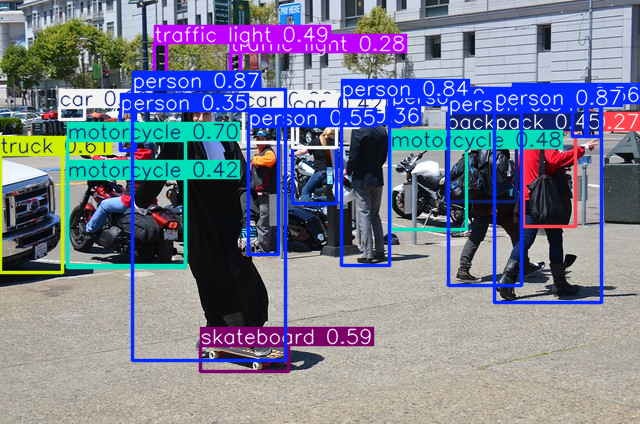

In [ ]:
# 시각화 결과 확인
results[0].save("detected.jpg")     # 탐지 결과 이미지 저장
results[0].show()                   # 시각화

# Image Segmentation with UNet


In [ ]:
# 1. Data preparation
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import random

# 간단한 도형 이미지를 생성하는 함수
def generate_shape_image(size=64):
  img = Image.new("L", (size, size), 0)  # 흑백, 배경 0
  draw = ImageDraw.Draw(img)
  shape_type = random.choice(["circle", "sqaure"])
  x1, y1 = random.randint(5, 25), random.randint(5, 25)
  x2, y2 = x1 + random.randint(20, 35), y1 + random.randint(20, 35)

  if shape_type == "circle":
    draw.ellipse((x1, y1, x2, y2), fill=255)
  else:
    draw.rectangle((x1, y1, x2, y2), fill=255)

  return np.array(img, dtype=np.float32) / 255.0


# Dataset 정의
class ShapeDataset(Dataset):
  def __init__(self, n=200):
    self.images = [generate_shape_image() for _ in range(n)]

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    img = self.images[idx]
    # 입력 이미지와 정답 마스크를 동일한 배열로 사용하는 합성 분할 예제
    return torch.tensor(img).unsqueeze(0), torch.tensor(img)

dataset = ShapeDataset()
loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
ㅑ# 2. Model
import torch.nn as nn
import torch.nn.functional as F

class UNetMini(nn.Module):
  def __init__(self):
    super().__init__()

    # 인코더
    self.enc1 = nn.Sequential(
        nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
        nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
    )  # output: (B, 8, 64, 64)
    self.enc2 = nn.Sequential(
        nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
        nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
    )  # output: (B, 16, 32, 32)

    # 디코더
    self.dec1 = nn.Sequential(
        nn.Conv2d(24, 16, 3, padding=1), nn.ReLU(),
        nn.Conv2d(16, 16, 3, pading=1), nn.ReLU()
    )  # output: (B, 16, 64, 64)

    self.final = nn.Conv2d(16, 1, 1) # output: (B, 1, 64, 64)

    self.pool = nn.MaxPool2d(2)

  def forward(self, x):
    x1 = self.enc1(x)   # (B, 8, 64, 64)
    x2 = self.pool(x1)  # (B, 8, 32, 32)
    x2 = self.enc2(x2)  # (B, 16, 32, 32)

    # 업샘플링 + 스킵 연결
    x3 = F.interpolate(x2, scale_factor=2, mode="bilinear", align_corners=False)  # (B, 16, 64, 64)
    x_cat = torch.cat([x1, x3], dim=1)  # (B, 8+16=24, 64, 64)

    # 디코더
    x4 = self.dec1(x_cat)  # (B, 16, 64, 64)
    out = torch.sigmoid(self.final(x4))  # (B, 1, 64, 64)

    return out

model = UNetMini()

In [ ]:
# UNet model

import torch
import torch.nn as nn
import torch.nn.functional as F

class UNetMini(nn.Module):
  def __init__(self):
    super().__init__()

    self.enc1 = nn.Sequential(
        nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
        nn.Conv2d(8, 8, 3, padding=1), nn.ReLU()
    )  # output : (B, 8, 64, 64)

    self.enc2 = nn.Sequential(
        nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
        nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
    )  # output: (B, 16, 32, 32)

    self.dec1 = nn.Sequential(
        nn.Conv2d(24, 16, 3, padding=1), nn.ReLU(),
        nn.Conv2d(16, 16, 3, padding=1), nn.ReLU()
    )  # output: (B, 16, 64, 64)

    self.final = nn.Conv2d(16, 1, 1)  # output: (B, 1, 64, 64)

    self.pool = nn.MaxPool2d(2)

  def forward(self, x):
    # encoder
    x1 = self.enc1(x) # B, 8, 64, 64
    x2 = self.pool(x1)  # B, 8, 32, 32
    x2 = self.enc2(x2)  # B, 16, 32, 32

    # upsampling
    x3 = F.interpolate(x2, scale_factor=2, mode="bilinear", align_corners=False)  # B, 16, 64, 64

    # skip connection
    x_cat = torch.cat([x1, x3], dim=1)  # B, 24, 64, 64

    # decoder
    x4 = self.dec1(x_cat)  # B, 16, 64, 64
    out = torch.sigmoid(self.final(x4))  # B, 1, 64, 64

    return out

model = UNetMini()

In [ ]:
# Loss function & optimizer

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training loop
num_epochs = 5

for epoch in range(num_epochs):
  total_loss = 0.0
  for images, masks in loader:
    # images: (8, 1, 64, 64)
    # masks: (8, 64, 64)

    optimizer.zero_grad()
    preds = model(images).squeeze(1)  # 8, 64, 64

    loss = criterion(preds, masks)
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


Epoch 1, Loss: 12.7248
Epoch 2, Loss: 1.2520
Epoch 3, Loss: 0.1883
Epoch 4, Loss: 0.1535
Epoch 5, Loss: 0.1252


In [ ]:
# Training loop
num_epochs = 5

for epoch in range(num_epochs):
  total_loss = 0.0
  for images, masks in loader:
    # image: 8, 1, 64, 64 / masks: 8, 64, 64
    optimizer.zero_grad():
    preds = model(images).squeeze(1)
    loss = criterion(preds, masks)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  print(f"Epoch {epoch+1. Loss: {total_loss:.4f}}")

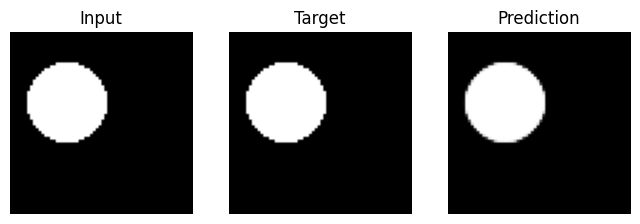

In [ ]:
# Visualization

model.eval()
sample_img, sample_mask = dataset[0]
with torch.no_grad():
  pred = model(sample_img.unsqueeze(0)).squeeze().numpy()

plt.figure(figsize=(8,3))
plt.subplot(1, 3, 1)
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title("Input")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sample_mask, cmap='gray')
plt.title("Target")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap='gray')
plt.title("Prediction")
plt.axis('off')

plt.show()

# Machine Translation with Seq2seq

In [2]:
# 1. 토이 번역 데이터 구성
import torch
from torch.utils.data import Dataset, DataLoader

pairs = [
    ("i love you", "나는 너를 사랑해"),
    ("he is happy", "그는 행복하다"),
    ("she is a student", "그녀는 학생이다"),
    ("thank you", "고마워"),
    ("good morning", "좋은 아침")
]

# Simple tokenizer
def tokenize(sentence):
  return sentence.split()

# Vocabulary
src_vocab = {"<pad>":0, "<sos>":1, "<eos>":2}
tgt_vocab = {"<pad>":0, "<sos>":1, "<eos>":2}

for src, tgt in pairs:
  for w in tokenize(src):
    if w not in src_vocab:
      src_vocab[w] = len(src_vocab)
  for w in tokenize(tgt):
    if w not in tgt_vocab:
      tgt_vocab[w] = len(tgt_vocab)

inv_tgt = {v:k for k,v in tgt_vocab.items()}

max_len = 8

def encode(sentence, vocab):
  tokens = ["<sos>"] + tokenize(sentence) + ["<eos>"]
  tokens = tokens[:max_len] + ["<pad>"]*(max_len - len(tokens))
  return torch.tensor([vocab[t] for t in tokens])

class ToyTranslationDataset(Dataset):
  def __init__(self, pairs):
    self.pairs = pairs

  def __len__(self):
    return len(self.pairs)

  def __getitem__(self, idx):
    src, tgt = self.pairs[idx]
    src_encoded = encode(src, src_vocab)  # shape: (max_len,)
    tgt_encoded = encode(tgt, tgt_vocab)  # shape: (max_len,)
    return src_encoded, tgt_encoded

dataset = ToyTranslationDataset(pairs)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

In [3]:
# 2. Bahdanau attention
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
  def __init__(self, hidden_size):
    super().__init__()
    self.W1 = nn.Linear(hidden_size, hidden_size)
    self.W2 = nn.Linear(hidden_size, hidden_size)
    self.V = nn.Linear(hidden_size, 1)

  def forward(self, decoder_hidden, encoder_outputs):
    # decoder_hidden: (B, H)
    # encoder_outputs: (B, T, H)
    # score: (B, T, 1)
    score = self.V(torch.tanh(self.W1(encoder_outputs) + self.W2(decoder_hidden).unsqueeze(1)))
    attn_weights = F.softmax(score, dim=1)  # (B, T, 1)
    context = (attn_weights * encoder_outputs).sum(dim=1)  # (B, H)
    return context, attn_weights

In [ ]:
# Bahdanau attention

import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
  def __init__(self, hidden_size):
    super().__init__()
    self.W1 = nn.Linear(hidden_size, hidden_size)
    self.W2 = nn.Linear(hidden_size, hidden_size)
    self.V = nn.Linear(hidden_size, 1)

  def forward(self, decoder_hidden, encoder_outputs):
    # d : B, H
    # e : B, T, H
    # s : B, T, 1
    score = self.V(self.W1(encoder_outputs)+self.W2(decoder_hidden).unsqueeze(1))
    attn_weights = F.softmax(dim=1) # B, T, 1
    context = (attn_weights*encoder_outputs).sum(dim=1)  # B, H

    return context, attn_weights

In [4]:
# 3. Encoder-Decoder model
class Encoder(nn.Module):
  def __init__(self, vocab_size, embed_size, hidden_size):
    super().__init__()
    self.embed = nn.Embedding(vocab_size, embed_size)
    self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

  def forward(self, x):
    # x: (B, T)
    x = self.embed(x)  # (B, T, E)
    outputs, (h, c) = self.lstm(x)  # (B, T, H)
    return outputs, (h, c)

class Decoder(nn.Module):
  def __init__(self, vocab_size, embed_size, hidden_size, attention):
    super().__init__()
    self.embed = nn.Embedding(vocab_size, embed_size)
    self.lstm = nn.LSTM(embed_size + hidden_size, hidden_size, batch_first=True)
    self.attn = attention
    self.fc = nn.Linear(hidden_size, vocab_size)

  def forward(self, x, hidden, cell, encoder_outputs):
    # x: (B,) 단일토큰
    x = self.embed(x).unsqueeze(1)  # B, 1, E

    # 디코더 현재 은닉 상태
    decoder_hidden = hidden[-1]  # B, H

    # 어텐션 계산
    context, _ = self.attn(decoder_hidden, encoder_outputs)  # B, H
    context = context.unsqueeze(1)  # B, 1, H

    # LSTM 입력 결합
    lstm_input = torch.cat([x, context], dim=2)  # B, 1, E+H

    outputs, (h, c) = self.lstm(lstm_input, (hidden, cell))  # outputs: B, 1, H
    logits = self.fc(outputs.squeeze(1))  # B, V
    return logits, (h, c)

class Seq2seq(nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def forward(self, src, tgt):
    encoder_outputs, (h, c) = self.encoder(src)

    batch_size = src.size(0)
    T = tgt.size(1)

    outputs = []
    token = tgt[:, 0]   # <sos>

    for t in range(1, T):
      logits, (h, c) = self.decoder(token, h, c, encoder_outputs)
      outputs.append(logits.unsqueeze(1))
      token = tgt[:, t]  # teacher forcing

    return torch.cat(outputs, dim=1)  # (B, T-1, V)

In [ ]:
# Encoder-decoder model

class Encoder(nn.Module):
  def __init__(self, vocab_size, embed_size, hidden_size):
    super().__init__()
    self.embed = nn.Embedding(vocab_size, embed_size)
    self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)

  def forward(self, x):
    # x: (B, T)
    x = self.embed(x)  # B, T, E
    outputs, (h, c) = self.lstm(x)  # outputs: B, T, H
    return outputs, (h, c)

class Decoder(nn.Module):
  def __init__(self, vocab_size, embed_size, hidden_size, attention):
    super().__init__()
    self.embed = nn.Embedding(vocab_size, embed_size)
    self.lstm = nn.LSTM(embed_size+hidden_size, hidden_size, batch_first=True)
    self.attn = attention
    self.fc = nn.Linear(hidden_size, vocab_size)

  def forward(self, x, hidden, cell, encoder_outputs):
    # x: (B,) 단일토큰
    x = self.embed(x).unsqueeze(1)  # B, 1, E

    decoder_hidden = hidden[-1]  # B, H

    context, _ = self.attn(decoder_hidden, encoder_outputs)  # B, H
    context = context.unsqueeze(1)  # B, 1, H

    lstm_input = torch.cat([x, context], dim=2)  # B, 1, E+H

    outputs, (h, c) = self.lstm(lstm_input, (hidden, cell))  # outputs: B, 1, H
    logits = self.fc(outputs.squeeze(1)) # B, V
    return logits, (h, c)

class Seq2seq(nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def forward(self, src, tgt):
    encoder_outputs, (h, c) = self.encoder(src)

    batch_size = src.size(0)
    T = tgt.size(1)

    outputs = []
    token = tgt[:, 0]

    for t in range(1, T):
      logits, (h, c) = self.decoder(token, h, c, encoder_outputs)
      outputs.append(logits.unsqueeze(1))
      token = tgt[:, t]

    return torch.cat(outputs, dim=1)



In [6]:
# 4. 학습 준비
embed_size = 32
hidden_size = 64

attention = BahdanauAttention(hidden_size)
encoder = Encoder(len(src_vocab), embed_size, hidden_size)
decoder = Decoder(len(tgt_vocab), embed_size, hidden_size, attention)
model = Seq2seq(encoder, decoder)

criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab["<pad>"])
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
# 5. 학습 루프 실행
num_epochs = 30

for epoch in range(num_epochs):
  total_loss = 0.0
  for src, tgt in loader:
    optimizer.zero_grad()
    logits = model(src, tgt)  # B, T-1, V

    loss = criterion(
        logits.reshape(-1, logits.size(-1)),
        tgt[:, 1:].reshape(-1)  # <sos> 다음 토큰부터 비교
    )

    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")



Epoch 1, Loss: 7.6958
Epoch 2, Loss: 7.5821
Epoch 3, Loss: 7.4319
Epoch 4, Loss: 7.2702
Epoch 5, Loss: 7.1570
Epoch 6, Loss: 6.9962
Epoch 7, Loss: 6.8917
Epoch 8, Loss: 6.6633
Epoch 9, Loss: 6.4072
Epoch 10, Loss: 6.1250
Epoch 11, Loss: 5.7732
Epoch 12, Loss: 5.5508
Epoch 13, Loss: 5.3165
Epoch 14, Loss: 5.1336
Epoch 15, Loss: 5.0633
Epoch 16, Loss: 4.6052
Epoch 17, Loss: 4.4914
Epoch 18, Loss: 4.4154
Epoch 19, Loss: 4.0462
Epoch 20, Loss: 3.8021
Epoch 21, Loss: 3.8229
Epoch 22, Loss: 3.5482
Epoch 23, Loss: 3.4580
Epoch 24, Loss: 3.1776
Epoch 25, Loss: 3.0994
Epoch 26, Loss: 2.8523
Epoch 27, Loss: 2.6648
Epoch 28, Loss: 2.5050
Epoch 29, Loss: 2.2734
Epoch 30, Loss: 2.3452


In [11]:
# 학습 루프
num_epochs = 30
for epoch in range(num_epochs):
  total_loss = 0.0
  for src, tgt in loader:
    optimizer.zero_grad()
    logits = model(src, tgt)

    loss = criterion(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 2.0623
Epoch 2, Loss: 1.9930
Epoch 3, Loss: 1.8160
Epoch 4, Loss: 1.7902
Epoch 5, Loss: 1.6729
Epoch 6, Loss: 1.4356
Epoch 7, Loss: 1.4365
Epoch 8, Loss: 1.2089
Epoch 9, Loss: 1.2525
Epoch 10, Loss: 1.1231
Epoch 11, Loss: 0.9603
Epoch 12, Loss: 0.9399
Epoch 13, Loss: 0.8708
Epoch 14, Loss: 0.7868
Epoch 15, Loss: 0.7320
Epoch 16, Loss: 0.7631
Epoch 17, Loss: 0.6624
Epoch 18, Loss: 0.5984
Epoch 19, Loss: 0.5860
Epoch 20, Loss: 0.5420
Epoch 21, Loss: 0.5278
Epoch 22, Loss: 0.4964
Epoch 23, Loss: 0.4533
Epoch 24, Loss: 0.4428
Epoch 25, Loss: 0.4457
Epoch 26, Loss: 0.4011
Epoch 27, Loss: 0.3942
Epoch 28, Loss: 0.3590
Epoch 29, Loss: 0.3510
Epoch 30, Loss: 0.3743


In [16]:
# 6. Translation
def translate(sentence):
  src = encode(sentence, src_vocab).unsqueeze(0)
  encoder_outputs, (h, c) = encoder(src)

  token = torch.tensor([tgt_vocab["<sos>"]])
  result = []

  for _ in range(max_len):
    logits, (h, c) = decoder(token, h, c, encoder_outputs)
    token = logits.argmax(dim=1)
    word = inv_tgt[token.item()]
    if word == "<eos>":
      break
    result.append(word)
  return " ".join(result)

print(translate("i love you"))
print(translate("good morning"))

나는 너를 사랑해
좋은 아침


In [19]:
# translation
def translate(sentence):
  src = encode(sentence, src_vocab).unsqueeze(0)
  encoder_outputs, (h, c) = encoder(src)

  token = torch.tensor([tgt_vocab["<sos>"]])
  result = []

  for _ in range(max_len):
    logits, (h, c) = decoder(token, h, c, encoder_outputs)
    token = logits.argmax(dim=1)
    word = inv_tgt[token.item()]
    if word == "<eos>":
      break
    result.append(word)
  return " ".join(result)

print(translate("he is happy"))
print(translate('i love morning'))
print(translate('he love you'))
print(translate('she is good'))
print(translate('happy morning'))

그는 행복하다
나는 너를 사랑해
나는 너를 사랑해
그녀는 학생이다
좋은 아침
